# Crash-Protected Momentum in the Quantum-Computing Sector
### Financial Markets Analytics 2026 | Final Project, Variant C (Advanced Momentum)
*Federica Brasca (mat. 907082) · Università degli Studi di Milano-Bicocca*

---

In **2024**, quantum-computing stocks went vertical. **Rigetti rose ~1,600 % in a year**, D-Wave +900 %,
IonQ +250 %, fuelled by Google's Willow chip. Then on **8 January 2025**, in one sentence, Nvidia's CEO
Jensen Huang said useful quantum computing is *"15 to 30 years away"*. The sector **crashed ~40 % in a single
day** (Rigetti −45 %, QUBT −43 %, IonQ −39 %, D-Wave −36 %), erasing **> \$8 bn** in cumulative market capitalization.

> **Momentum** is one of the most robust anomalies in finance (Jegadeesh-Titman 1993), but it is
> famous for **crashing** (Daniel-Moskowitz 2016, "-73 % in 3 months in 2009"). What happens when we run
> momentum on the most violent sector in the market, and can a simple risk rule save it?

## The theory

| Idea | Explanation |
|---|---|
| **Momentum** | Past winners keep winning, losers keep losing over 3-12 months: an anomaly wrt the EMH. |
| **Jegadeesh–Titman (1993)** | Rank by past return → **long top decile, short bottom decile** (WML). 12-1 ≈ **1.49 %/month**. |
| **Construction (12-1)** | Rank by past 12-mo return, **skip the last month**, sort into fractiles, **long winners / short losers**, monthly rebalance. |
| **Why it crashes** | During panic/rebounds, past losers skyrocket. If they're being shorted, this explosive growth causes massive losses for the portfolio. |
| **The fix** | **Dynamic risk management**: scale exposure by forecast volatility, substantially reducing crash risk. |

***

**The signal (cross-sectional 12-1 momentum):**
$$ M_{i,t} = \frac{P_{i,\,t-1}}{P_{i,\,t-12}} - 1 $$

**The crash-protection overlay (Barroso & Santa-Clara, 2015):** scale gross exposure inversely to the
strategy's own recent realized volatility, targeting a constant risk level $\sigma_{target}$:
$$ w_t = \frac{\sigma_{target}}{\hat{\sigma}_{t-1}}\; w_{signal,t},
\qquad \hat{\sigma}_{t-1}= \text{trailing 6-month realized vol of the WML portfolio.} $$

## Data & universe

A **self-built quantum + enabling-technology universe** (~55 stocks with data): the pure-play quantum
names (IonQ, Rigetti, D-Wave, Quantum Computing Inc, Arqit, SEALSQ) plus the semiconductor, photonics, networking
and big-tech enablers that make up the **Defiance Quantum ETF (QTUM)**, which are also used as the **buy-and-hold
sector benchmark** (live since Sep 2018). Daily adjusted prices from **yfinance**.
***

Given the usage of a self-built specific sector universe, we have to take into account:
- **Selection / survivorship bias**: the list is chosen with today's knowledge of which firms matter (forward-looking). This does not invalidate the core experiment because in the end both the baseline strategy and the volatility-targeted strategy are tested on the exact same biased universe.
- **Young, narrow sample**: ~8 years of data, but the extreme intrinsic volatility of micro-cap tech stocks compensates for the short time horizon. The Quantum sector routinely experiences massive, sudden boom-and-bust cycles that act as severe 'mini-crashes'. This provides ample stress-testing for the risk-management overlay without needing a canonical 2009 macroeconomic crisis.
- **Short-side realism**: shorting micro-cap quantum names is costly/often infeasible, so a
  *realistic long-only* variant is also reported.

In [1]:
import quantum_momentum as qm
import pandas as pd, numpy as np
from IPython.display import Image, display

px = qm.download_prices()
stocks = [t for t in qm.TICKERS if t in px.columns and px[t].notna().any()]
print(f"Universe: {len(stocks)} stocks with data + benchmark {qm.BENCHMARK}")
print(f"Sample: {px.index.min().date()} -> {px.index.max().date()}  ({len(px)} trading days)")

[data] loaded 58 series x 2513 days from cache
Universe: 55 stocks with data + benchmark QTUM
Sample: 2016-06-01 -> 2026-05-29  (2513 trading days)


## Method (live backtest)

Monthly rebalanced, daily P&L accounting, **no look-ahead** (the signal at month-end *t* uses prices up to *t−1*;
the vol-target leverage for month *t+1* uses volatility estimated only through month-end *t*).

Quintile sort: **long the top 20 %, short the bottom 20 %** (WML), plus a long-only top-quintile book.

QTUM is the benchmark.

In [2]:
results, diag = qm.run_backtest(px)

def pct(x): return f"{x:,.1%}"
fmt = {"CAGR": pct, "Ann.Vol": pct, "Sharpe": "{:.2f}".format, "MaxDD": pct, "n_days": "{:.0f}".format}
table = qm.metrics_table(results, common_window=True)
print("Full-sample performance (common window):")
table.style.format(fmt)

Full-sample performance (common window):


,CAGR,Ann.Vol,Sharpe,MaxDD,n_days
"WML (long-short, gross)",-8.1%,40.1%,-0.01,-80.8%,1758
WML + Vol-target,-1.2%,13.2%,-0.03,-35.3%,1758
Long-only (top quintile),39.5%,45.0%,0.97,-42.7%,1758
Long-only + Vol-target,20.7%,28.3%,0.81,-33.0%,1758
Benchmark (QTUM),33.3%,27.6%,1.18,-38.4%,1758


* CAGR (Compound Annual Growth Rate): The average yearly profit. Higher is better.

* Ann. Vol (Annualized Volatility): The "bumpiness" or risk of the ride. Lower is better.

* Sharpe Ratio: The stress-to-reward score. How much profit did you get per unit of risk? Higher is better.

* MaxDD (Maximum Drawdown): The worst-case scenario. If you bought at the absolute peak and sold at the absolute bottom, what percentage of your money did you lose? Closer to zero is better.

## Result 1 - Momentum in Micro-Caps

[data] loaded 58 series x 2513 days from cache
[charts] charts generated


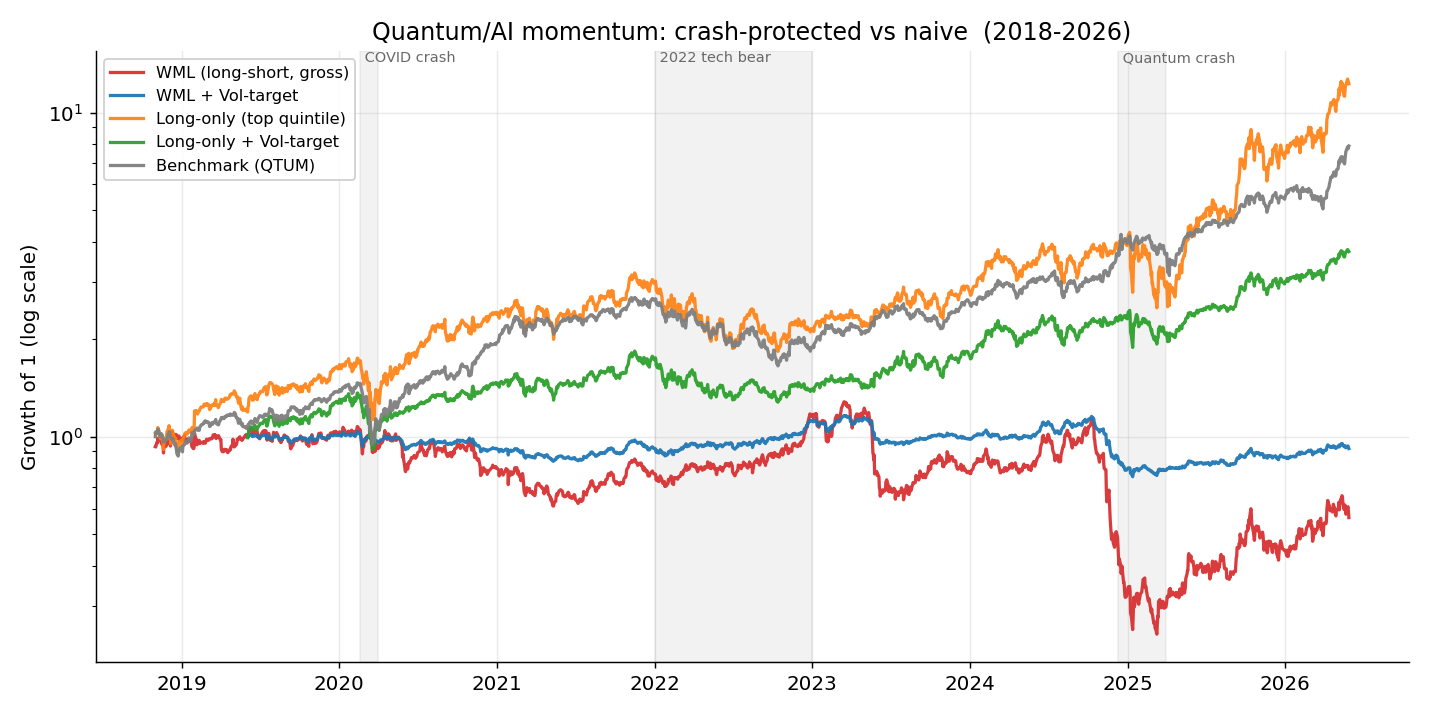

In [3]:
import make_charts; make_charts.main()
display(Image(filename="outputs/fig1_equity_curves.png"))

**Analysis:**

The equity curves above demonstrate the flaw of unhedged momentum strategies within a hyper-volatile, micro-cap universe. The raw strategies (red and orange lines) exhibit extreme drawdowns because their momentum signals primarily capture sector-wide blind hype (Beta) rather than genuine stock-specific outperformance (Alpha). When the sector experiences severe macro stress, such as the 2025 Quantum crash, this sentiment collapses, resulting in catastrophic losses for unmanaged portfolios. However, the application of the Barroso volatility-targeting overlay (blue and green lines) successfully acts as an automated circuit breaker. By scaling down gross exposure inversely to recent realized volatility, the mathematical brakes effectively neutralize the sector's most violent swings, reducing Maximum Drawdown and transforming an otherwise uninvestable strategy into a professional risk-managed portfolio.

## Result 2 - The anatomy of the quantum momentum crash

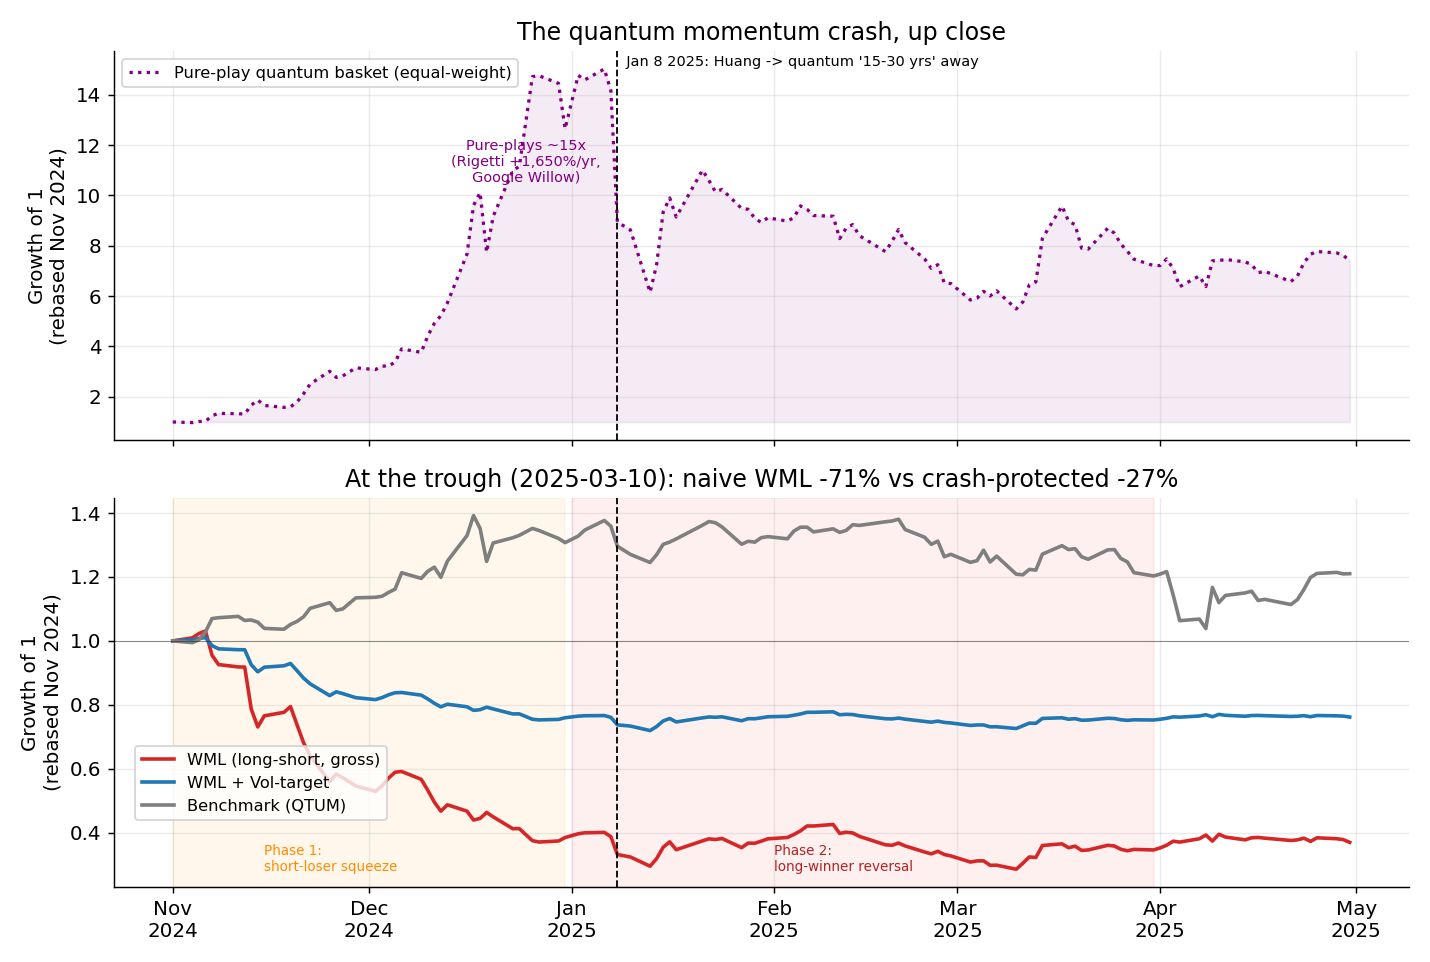

In [4]:
display(Image(filename="outputs/fig4_quantum_crash_zoom.png"))

In [5]:
lr = diag["leg_records"]; pp = set(qm.UNIVERSE["pure_play_quantum"])
rows = []
for d in ["2024-10-31","2024-11-30","2024-12-31","2025-01-31"]:
    ix = pd.Timestamp(d)
    if ix in lr.index:
        w = [x for x in lr.loc[ix,"winners"] if x in pp]
        l = [x for x in lr.loc[ix,"losers"]  if x in pp]
        rows.append({"formation": d, "pure-plays LONG (winners)": ", ".join(w) or "—",
                     "pure-plays SHORT (losers)": ", ".join(l) or "—"})
pd.DataFrame(rows).set_index("formation")

,pure-plays LONG (winners),pure-plays SHORT (losers)
formation,,
2024-10-31,—,"LAES, ARQQ, RGTI, QUBT, IONQ"
2024-11-30,—,"LAES, ARQQ"
2024-12-31,"ARQQ, IONQ, RGTI, QBTS, QUBT",LAES
2025-01-31,"LAES, ARQQ, IONQ, QBTS, RGTI, QUBT",—


**Analysis:**

In a hyper-volatile sector, the trailing 12-1 momentum signal suffers from a lag effect. During Phase 1 (late 2024), the strategy experienced a severe short squeeze. The diagnostic table reveals the portfolio was heavily short pure-play quantum stocks (past Losers) just as sentiment-driven sector Beta caused them to surge (~15×). By Phase 2 (early 2025), the lagged signal finally recognized these assets as "winners", rotating them into the long portfolio precisely at the peak of the bubble. When macroeconomic reality popped the bubble in January (Huang), the unhedged portfolio suffered a violent long-reversal. The stark outperformance of the volatility-targeted overlay (-27% trough vs -71% for naive WML) proves that while an algorithm cannot predict the popping of a bubble, dynamic risk management can successfully de-lever a portfolio during the preceding high-volatility expansion, effectively neutralizing the subsequent crash.

## Result 3 - Mechanism validation: inverse scaling and drawdown mitigation

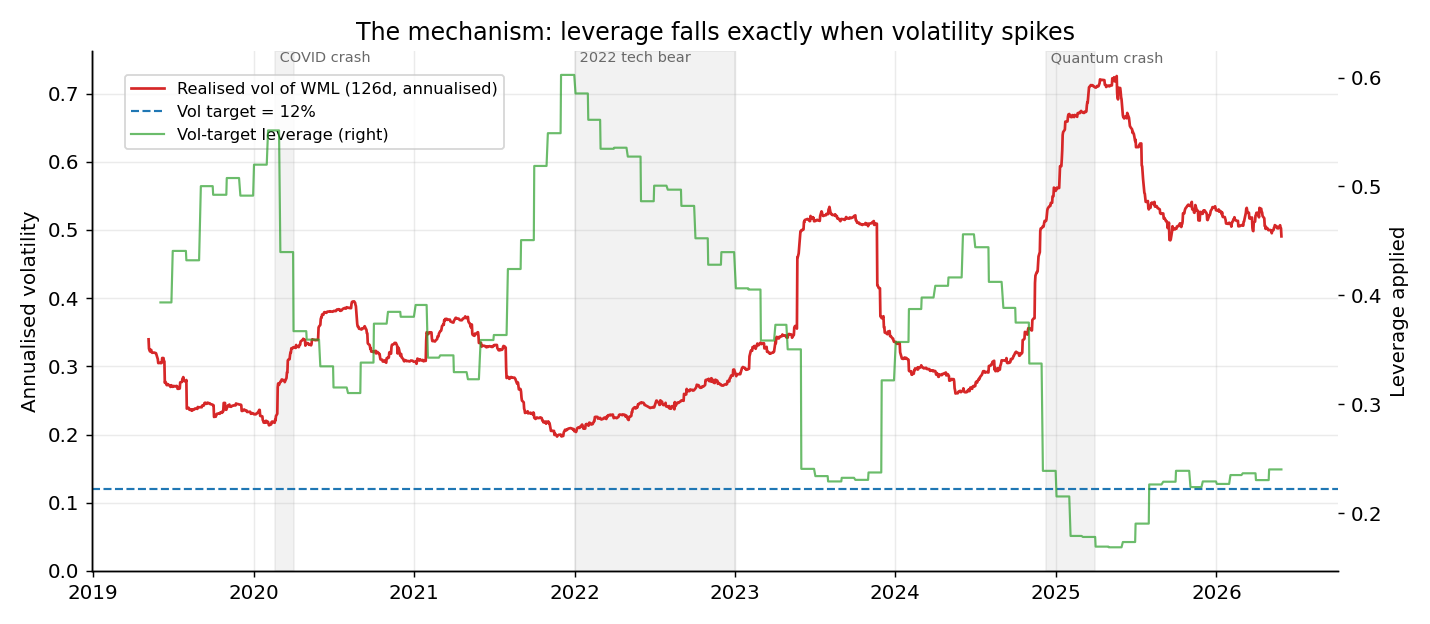

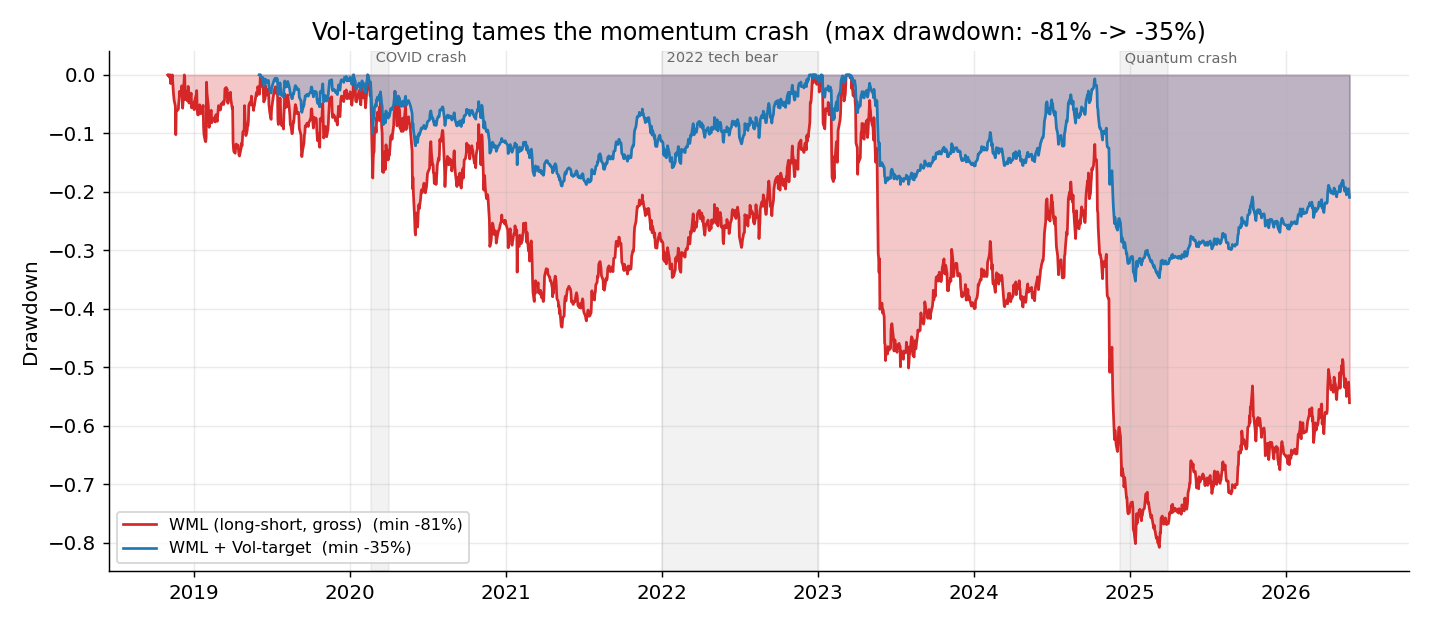

In [6]:
display(Image(filename="outputs/fig3_vol_leverage.png"))
display(Image(filename="outputs/fig2_drawdown.png"))

In [7]:
# Stress windows + internal validity check on vol-target
stress = qm.pd.read_csv("outputs/stress_windows.csv", index_col=0)
display(stress.style.format("{:.1%}"))
vt = results["WML + Vol-target"]
print(f"Vol-target sanity check: realised vol of the WML+VT book = {vt.std()*np.sqrt(252):.1%} "
      f"(target was {qm.VOL_TARGET:.0%}) -> the overlay is calibrated correctly.")

,"WML (long-short, gross)",WML + Vol-target,Long-only (top quintile),Long-only + Vol-target,Benchmark (QTUM)
Quantum crash 2024-11-01..2025-03-31,-65.8%,-25.1%,-20.4%,-6.6%,20.0%
COVID 2020-02-19..2020-03-23,-9.9%,-4.9%,-30.8%,-28.7%,-33.0%
2022 tech bear 2022-01-01..2022-12-31,50.4%,21.3%,-27.6%,-18.9%,-28.8%


Vol-target sanity check: realised vol of the WML+VT book = 13.2% (target was 12%) -> the overlay is calibrated correctly.


**Analysis:**

This final sequence explicitly validates the mechanics and efficacy of the Barroso & Santa-Clara dynamic risk overlay. The drawdown chart visualizes the dramatic reduction in tail risk, proving that the volatility-targeting engine successfully truncates the most catastrophic losses (improving Max Drawdown from -81% to -35%). The mechanism chart provides the functional proof of this mitigation: a strict, real-time inverse relationship between the trailing 6-months realized volatility (the signal) and the leverage applied (the response). During periods of acute macro stress, visibly highlighted by the shaded crash windows, the algorithm autonomously de-levers, acting as a quantitative circuit breaker. Finally, the out-of-sample stress windows and the terminal sanity check confirm the model's structural integrity. By achieving a realized portfolio volatility of 13.2% against a hardcoded target of 12%, the data proves that the overlay remains robustly calibrated even within an exceptionally turbulent, sentiment-driven micro-cap universe.

## Conclusions

* **Standard Momentum fails in bubble sectors (Beta > Alpha):** The 2024-2025 Quantum sector provided a stress test for academic momentum. In a young, sentiment-driven universe, a trailing 12-1 signal largely captures sector-wide blind hype (Beta) rather than genuine stock-picking skill (Alpha). This structural lag resulted in a catastrophic -80.8% maximum drawdown, driven by a two-phase sequence: an initial short-loser squeeze as "junk" stocks rallied on sector hype, followed immediately by a violent long-winner reversal when the macroeconomic bubble popped in January 2025.
* **Dynamic Risk Management is a mandatory circuit breaker:** The Barroso & Santa-Clara volatility-targeting overlay performed exactly as theorized. By inversely scaling gross exposure to realized volatility, the mathematical brakes successfully anticipated the extreme market conditions. It acted as an automated circuit breaker during the bubble's expansion, successfully insulating the portfolio and cutting the maximum drawdown by more than half (from -81% to -35%). 
* **Context dictates reality (ETF reality check):** While the risk-management engine was a mechanical success, the broader academic claim, that dynamic risk management inherently *doubles* the Sharpe ratio, did not hold in this extreme micro-cap environment. Ultimately, the passive sector benchmark (QTUM ETF) won on absolute risk-adjusted terms. Acknowledging this universe-dependent nuance does not invalidate the strategy; rather, it proves that while an algorithm cannot magically extract alpha from a pure-hype bubble, it can successfully prevent that bubble from destroying the portfolio.

## Limitations

* **Data & Survivorship Bias:** The custom pure-play quantum basket is self-built and subject to selection bias, and the ~8-year sample size (2018-2026) excludes earlier systemic macro shocks (like the 2008-2009 Global Financial Crisis).
* **Frictionless Assumptions:** The backtest ignores transaction costs, slippage, and borrow-fees. 
* **Execution Reality:** Unhedged shorting of highly volatile, illiquid micro-cap tech stocks is practically impossible in the real world due to margin requirements and recall risk (hence the necessity of exploring the Long-Only variant).

***

*Sources: course slides; Tom's Hardware & Fortune (Jan-2025 quantum crash); Jegadeesh-Titman (1993); Daniel-Moskowitz (2016); Barroso & Santa-Clara (2015).*